In [1]:
# ==============================
#  DERMATOLOGY AI PROJECT SETUP
# ==============================

import os
import zipfile
import numpy as np
import tensorflow as tf
from google.colab import drive

print("Mounting Google Drive...")
drive.mount('/content/drive')

# Define project path
PROJECT_PATH = "/content/drive/MyDrive/Dermatology_AI_Project"
DATASET_PATH = f"{PROJECT_PATH}/datasets"

# ZIP file paths
ISIC_ZIP = f"{DATASET_PATH}/ISIC2018_segmentation.zip"
HAM_ZIP = f"{DATASET_PATH}/HAM10000.zip"

print("Project Path:", PROJECT_PATH)
print("Dataset Path:", DATASET_PATH)

# Move to project directory
os.chdir(PROJECT_PATH)
print("Current Working Directory:", os.getcwd())

Mounting Google Drive...
Mounted at /content/drive
Project Path: /content/drive/MyDrive/Dermatology_AI_Project
Dataset Path: /content/drive/MyDrive/Dermatology_AI_Project/datasets
Current Working Directory: /content/drive/MyDrive/Dermatology_AI_Project


In [2]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

In [3]:
os.listdir("/content/drive/MyDrive/Dermatology_AI_Project/models")

['mobilenet_best.h5',
 'mobilenet_finetuned_final.keras',
 'mobilenet_finetuned.h5',
 'unet_segmentation_best.h5',
 'unet_segmentation_best.keras']

In [4]:
import tensorflow as tf

# Load Segmentation Model
seg_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Dermatology_AI_Project/models/unet_segmentation_best.keras",
    compile=False
)

# Load Classification Model
cls_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Dermatology_AI_Project/models/mobilenet_finetuned_final.keras"
)

print("✅ Segmentation Model Loaded")
print("✅ Classification Model Loaded")

✅ Segmentation Model Loaded
✅ Classification Model Loaded


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 31 variables whereas the saved optimizer has 60 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [5]:
import cv2
import numpy as np

SEG_SIZE = 128
CLS_SIZE = 224

def preprocess_image(img_path):

    img = cv2.imread(img_path)

    if img is None:
        raise ValueError("Image not found. Check the path!")

    # image for segmentation
    img_seg = cv2.resize(img, (SEG_SIZE, SEG_SIZE))
    img_seg = img_seg / 255.0
    img_seg = np.expand_dims(img_seg, axis=0)

    return img, img_seg

In [6]:
def get_segmentation_mask(img_input):

    mask = seg_model.predict(img_input)[0]

    mask = (mask > 0.5).astype(np.uint8)

    return mask

In [7]:
def extract_roi(original_img, mask):

    mask = cv2.resize(mask, (original_img.shape[1], original_img.shape[0]))

    mask_binary = (mask > 0.5).astype("uint8")

    contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return original_img

    largest_contour = max(contours, key=cv2.contourArea)

    x, y, w, h = cv2.boundingRect(largest_contour)

    roi = original_img[y:y+h, x:x+w]

    return roi

In [8]:
def classify_roi(roi):

    roi = cv2.resize(roi, (224,224))
    roi = roi / 255.0
    roi = np.expand_dims(roi, axis=0)

    prediction = cls_model.predict(roi)

    class_idx = np.argmax(prediction)
    confidence = prediction[0][class_idx]

    return class_idx, confidence, prediction

In [9]:
class_names = [
    "Melanocytic Nevus (nv)",
    "Melanoma (mel)",
    "Benign Keratosis (bkl)",
    "Basal Cell Carcinoma (bcc)",
    "Actinic Keratosis (akiec)",
    "Vascular Lesion (vasc)",
    "Dermatofibroma (df)"
]

In [10]:
from google.colab import files
uploaded = files.upload()

Saving lesion.jpg to lesion (1).jpg


In [11]:
img_path = "/content/drive/MyDrive/Dermatology_AI_Project/lesion.jpg"

In [12]:
def visualize_pipeline(original_img, mask, roi, label, confidence):

    mask_display = cv2.resize(mask, (original_img.shape[1], original_img.shape[0]))

    fig, axes = plt.subplots(1, 3, figsize=(15,5))

    # Original Image
    axes[0].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    # Segmentation Mask
    axes[1].imshow(mask_display, cmap="gray")
    axes[1].set_title("Segmentation Mask")
    axes[1].axis("off")

    # ROI + Prediction
    axes[2].imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
    axes[2].set_title(f"{label}\nConfidence: {confidence:.2f}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

In [17]:
def dermatology_predict(img_path):

    # Step 1: preprocess image
    original_img, img_input = preprocess_image(img_path)

    # Step 2: segmentation
    mask = get_segmentation_mask(img_input)

    # Step 3: ROI extraction
    roi = extract_roi(original_img, mask)

    # Step 4: classification
    class_idx, confidence, prediction = classify_roi(roi)

    label = class_names[class_idx]

    result = {
        "label": label,
        "confidence": float(confidence),
        "mask": mask,
        "roi": roi,
        "original": original_img
    }

    return result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step
Predicted Disease: Vascular Lesion (vasc)
Confidence: 0.9680553078651428


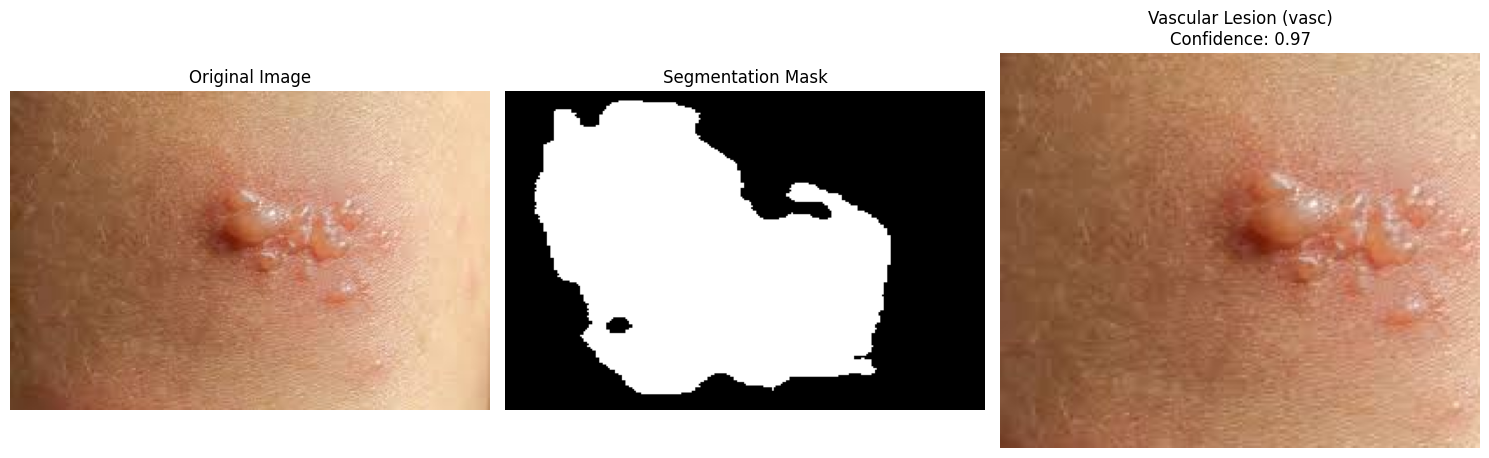

In [18]:
result = dermatology_predict(img_path)

print("Predicted Disease:", result["label"])
print("Confidence:", result["confidence"])

visualize_pipeline(
    result["original"],
    result["mask"][:,:,0],
    result["roi"],
    result["label"],
    result["confidence"]
)

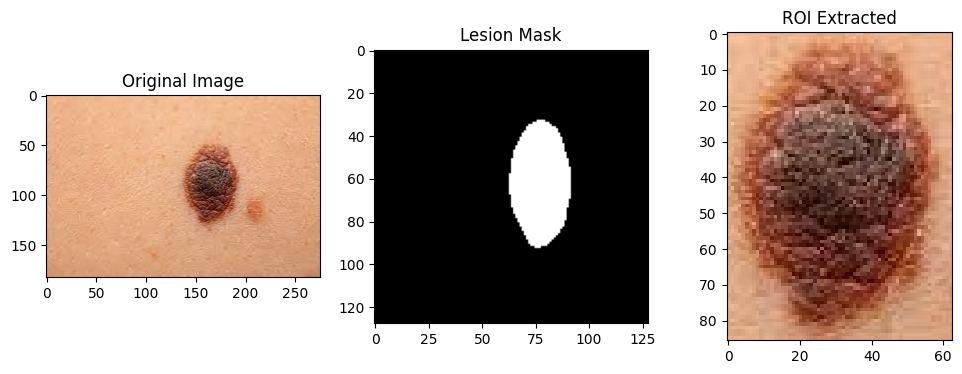

In [14]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))

plt.subplot(1,3,2)
plt.title("Lesion Mask")
plt.imshow(mask[:,:,0], cmap='gray')

plt.subplot(1,3,3)
plt.title("ROI Extracted")
plt.imshow(cv2.cvtColor(roi.astype('uint8'), cv2.COLOR_BGR2RGB))

plt.show()

In [15]:
import os

os.makedirs("/content/drive/MyDrive/Dermatology_AI_Project/test_images", exist_ok=True)

print("test_images folder created successfully")

test_images folder created successfully


In [19]:
for file in os.listdir(test_folder):

    img_path = os.path.join(test_folder, file)

    result = dermatology_predict(img_path)

    print(file, "→", result["label"], "(", result["confidence"], ")")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 863ms/step
lesion.jpg → Vascular Lesion (vasc) ( 0.8505125045776367 )
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step
lesion2.jpg → Vascular Lesion (vasc) ( 0.9680553078651428 )
